In [1]:
# Libs
import json
import os
import time
from collections import defaultdict
from fractions import Fraction
from math import gcd
from functools import reduce

import pandas as pd
from pymatgen.core import Composition

os.makedirs("Data", exist_ok=True)

In [2]:
ACTIVE_METALS = ["Li", "Na", "K", "Rb", "Cs", "Mg", "Ca", "Al", "Zn", "Y"]

VALENCE = {
    "Li": 1, "Na": 1, "K": 1, "Rb": 1, "Cs": 1,   # monovalen
    "Mg": 2, "Ca": 2, "Zn": 2,                     # divalen
    "Al": 3, "Y": 3,                               # trivalen
}

FARADAY = 96485.0   # C/mol
RATIO_TOL = 1e-6    # toleransi numerik

print(f"{len(ACTIVE_METALS)} ion aktif: {ACTIVE_METALS}")

10 ion aktif: ['Li', 'Na', 'K', 'Rb', 'Cs', 'Mg', 'Ca', 'Al', 'Zn', 'Y']


In [3]:
def fetch_mp_materials_batch(api_key, out_path="data/mp_raw.json", chunk_size=500, num_chunks=10):
    """Unduh & bersihkan material inorganik dari Materials Project per batch.
    
    Memproses data per batch untuk mengurangi beban memory.
    """
    from mp_api.client import MPRester

    records = []
    seen = set()
    
    with MPRester(api_key) as mpr:
        # Iterasi per batch untuk mengurangi beban
        for chunk_idx in range(num_chunks):
            print(f"[Batch {chunk_idx + 1}/{num_chunks}] Memproses...")
            
            docs = mpr.materials.summary.search(
                fields=["material_id", "formula_pretty", "composition",
                        "nsites", "volume", "energy_per_atom",
                        "uncorrected_energy_per_atom", "symmetry"],
                num_chunks=num_chunks,
                chunk_size=chunk_size,
            )
            
            batch_records = []
            for d in docs:
                try:
                    comp = d.composition
                    volume = d.volume
                    nsites = d.nsites
                    e_pa = (d.uncorrected_energy_per_atom
                            if d.uncorrected_energy_per_atom is not None
                            else d.energy_per_atom)
                    
                    if e_pa is None or volume is None or volume <= 0:
                        continue
                    
                    comp_dict = {str(el): int(round(amt))
                                 for el, amt in comp.get_el_amt_dict().items()}
                    sg = d.symmetry.number if d.symmetry else None
                    cs = str(d.symmetry.crystal_system) if d.symmetry else None
                    
                    key = (comp.reduced_formula, sg)
                    if key in seen:
                        continue
                    seen.add(key)
                    
                    batch_records.append({
                        "id": str(d.material_id),
                        "formula": d.formula_pretty,
                        "composition": comp_dict,
                        "nsites": int(nsites),
                        "volume": float(volume),
                        "energy_cell": float(e_pa * nsites),
                        "space_group": sg,
                        "crystal_system": cs,
                    })
                except Exception:
                    continue
            
            records.extend(batch_records)
            print(f"  └─ {len(batch_records)} materials (total: {len(records)})")
    
    with open(out_path, "w") as f:
        json.dump(records, f)
    print(f"[MP] {len(records)} material solid -> {out_path}")
    return records


# --- Jalankan dengan batch processing ---
API_KEY = "dCEo8TMkPHg4anT11uXbzHbajHfvOIIR"
# materials = fetch_mp_materials_batch(API_KEY, chunk_size=500, num_chunks=10)

In [4]:
# Load dan tampilkan data dengan pandas
df = pd.read_json("data/mp_raw.json")

print(f"Shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}\n")
print("First 5 rows:")
print(df.head())

print("\n\nInfo:")
print(df.info())

print("\n\nDescriptive statistics:")
print(df.describe())

Shape: (3818, 8)

Column types:
id                 object
formula            object
composition        object
nsites              int64
volume            float64
energy_cell       float64
space_group         int64
crystal_system     object
dtype: object

First 5 rows:
           id        formula                                     composition  \
0  mp-3346412  Na2CaMg(SO4)3  {'Na': 12, 'Ca': 6, 'Mg': 6, 'S': 18, 'O': 72}   
1  mp-3346398     CaMg(CO3)2             {'Ca': 3, 'Mg': 3, 'C': 6, 'O': 18}   
2  mp-3346453        LiMgCl3                    {'Li': 6, 'Mg': 6, 'Cl': 18}   
3  mp-3346415  CaMg15(CO3)16           {'Ca': 1, 'Mg': 15, 'C': 16, 'O': 48}   
4  mp-3346392     CaMg(CO3)2             {'Ca': 2, 'Mg': 2, 'C': 4, 'O': 12}   

   nsites       volume  energy_cell  space_group crystal_system  
0     114  1496.311135  -930.446643            1      Triclinic  
1      30   317.483993  -269.894833            2      Triclinic  
2      30   598.728603  -211.452592          148    

In [5]:
# Load dan tampilkan element reference energy
with open("data/element_ref_energy.json", "r") as f:
    elem_data = json.load(f)

df_elem = pd.DataFrame(list(elem_data.items()), columns=["Element", "Reference_Energy"])

print(f"Element Reference Energy - Shape: {df_elem.shape}")
print(f"\nColumn types:\n{df_elem.dtypes}\n")
print("Data:")
print(df_elem)

print("\n\nInfo:")
print(df_elem.info())

print("\n\nDescriptive statistics:")
print(df_elem.describe())

Element Reference Energy - Shape: (10, 2)

Column types:
Element              object
Reference_Energy    float64
dtype: object

Data:
  Element  Reference_Energy
0      Li         -2.386706
1      Na         -3.564181
2       K         -6.018264
3      Rb         -0.980534
4      Cs        -25.108453
5      Mg         -4.169304
6      Ca         -7.038294
7      Al         -6.732098
8      Zn         -8.910603
9       Y        -20.313601


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Element           10 non-null     object 
 1   Reference_Energy  10 non-null     float64
dtypes: float64(1), object(1)
memory usage: 292.0+ bytes
None


Descriptive statistics:
       Reference_Energy
count         10.000000
mean          -8.522204
std            7.916359
min          -25.108453
25%           -8.442525
50%           -6.375181
75%  

In [6]:
df

,id,formula,composition,nsites,volume,energy_cell,space_group,crystal_system
0,mp-3346412,Na2CaMg(SO4)3,"{'Na': 12, 'Ca': 6, 'Mg': 6, 'S': 18, 'O': 72}",114,1496.311135,-930.446643,1,Triclinic
1,mp-3346398,CaMg(CO3)2,"{'Ca': 3, 'Mg': 3, 'C': 6, 'O': 18}",30,317.483993,-269.894833,2,Triclinic
2,mp-3346453,LiMgCl3,"{'Li': 6, 'Mg': 6, 'Cl': 18}",30,598.728603,-211.452592,148,Trigonal
3,mp-3346415,CaMg15(CO3)16,"{'Ca': 1, 'Mg': 15, 'C': 16, 'O': 48}",80,754.484889,-692.205680,148,Trigonal
4,mp-3346392,CaMg(CO3)2,"{'Ca': 2, 'Mg': 2, 'C': 4, 'O': 12}",20,214.413183,-179.700132,14,Monoclinic
...,...,...,...,...,...,...,...,...
3813,mp-2229175,Sr4MgMn2Cu2(SO3)2,"{'Sr': 4, 'Mg': 1, 'Mn': 2, 'Cu': 2, 'S': 2, '...",17,267.986710,-98.640349,115,Tetragonal
3814,mp-2229219,MgNb4(O2F)4,"{'Mg': 1, 'Nb': 4, 'O': 8, 'F': 4}",17,285.267276,-133.367942,1,Triclinic
3815,mp-2229205,MgTa2(ReO6)2,"{'Mg': 1, 'Ta': 2, 'Re': 2, 'O': 12}",17,215.537598,-146.342767,6,Monoclinic
3816,mp-2229211,MgFe4(HO2)4,"{'Mg': 1, 'Fe': 4, 'H': 4, 'O': 8}",17,178.885755,-99.925993,6,Monoclinic


In [7]:
def fetch_element_reference_energy(api_key, out_path="data/element_ref_energy.json"):
    """Ambil energi/atom tiap logam aktif dalam fasa murni paling stabil."""
    from mp_api.client import MPRester

    e_metal = {}
    with MPRester(api_key) as mpr:
        for m in ACTIVE_METALS:
            docs = mpr.materials.summary.search(
                chemsys=m,
                fields=["material_id", "uncorrected_energy_per_atom",
                        "energy_per_atom", "energy_above_hull"],
            )
            if not docs:
                print(f"[WARN] tak ada fasa murni untuk {m}")
                continue
            best = min(docs, key=lambda x: (x.energy_above_hull
                                            if x.energy_above_hull is not None
                                            else 1e9))
            e = (best.uncorrected_energy_per_atom
                 if best.uncorrected_energy_per_atom is not None
                 else best.energy_per_atom)
            e_metal[m] = float(e)
            print(f"[E_M] {m}: {e:.4f} eV/atom ({best.material_id})")

    with open(out_path, "w") as f:
        json.dump(e_metal, f, indent=2)
    return e_metal


# e_metal = fetch_element_reference_energy(API_KEY)

In [8]:
# Load dan tampilkan element reference energy
with open("data/element_ref_energy.json", "r") as f:
    elem_data = json.load(f)

df_elem = pd.DataFrame(list(elem_data.items()), columns=["Element", "Reference_Energy"])

print(f"Element Reference Energy - Shape: {df_elem.shape}")
print(f"\nColumn types:\n{df_elem.dtypes}\n")
print("Data:")
print(df_elem)

print("\n\nInfo:")
print(df_elem.info())

print("\n\nDescriptive statistics:")
print(df_elem.describe())

Element Reference Energy - Shape: (10, 2)

Column types:
Element              object
Reference_Energy    float64
dtype: object

Data:
  Element  Reference_Energy
0      Li         -2.386706
1      Na         -3.564181
2       K         -6.018264
3      Rb         -0.980534
4      Cs        -25.108453
5      Mg         -4.169304
6      Ca         -7.038294
7      Al         -6.732098
8      Zn         -8.910603
9       Y        -20.313601


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Element           10 non-null     object 
 1   Reference_Energy  10 non-null     float64
dtypes: float64(1), object(1)
memory usage: 292.0+ bytes
None


Descriptive statistics:
       Reference_Energy
count         10.000000
mean          -8.522204
std            7.916359
min          -25.108453
25%           -8.442525
50%           -6.375181
75%  

In [9]:
df_elem

,Element,Reference_Energy
0,Li,-2.386706
1,Na,-3.564181
2,K,-6.018264
3,Rb,-0.980534
4,Cs,-25.108453
5,Mg,-4.169304
6,Ca,-7.038294
7,Al,-6.732098
8,Zn,-8.910603
9,Y,-20.313601


In [10]:
AFLUX_BASE = "http://aflow.org/API/aflux/"
AFLUX_KEYS = ("compound,species,composition,enthalpy_cell,"
              "volume_cell,spacegroup_relax,natoms")

def fetch_aflow_materials(out_path="data/aflow_raw.json",
                          n_per_page=1000, max_pages=50):
    """Unduh material AFLOW (terarah ke sistem yang memuat logam aktif)."""
    import requests
    records, seen = [], set()
    for metal in ACTIVE_METALS:
        page = 1
        while page <= max_pages:
            url = (f"{AFLUX_BASE}?{AFLUX_KEYS},species(*{metal}*),"
                   f"$paging({page},{n_per_page})")
            try:
                batch = requests.get(url, timeout=120).json()
            except Exception as e:
                print(f"[AFLOW] {metal} p{page} gagal: {e}")
                break
            if not batch:
                break
            for d in batch:
                try:
                    comp = Composition(d["compound"])
                    vol = float(d.get("volume_cell", 0) or 0)
                    en = d.get("enthalpy_cell")
                    if en is None or vol <= 0:
                        continue
                    cd = {str(el): int(round(a))
                          for el, a in comp.get_el_amt_dict().items()}
                    sg = d.get("spacegroup_relax")
                    sg = int(sg) if isinstance(sg, (int, float)) else None
                    key = (comp.reduced_formula, sg)
                    if key in seen:
                        continue
                    seen.add(key)
                    records.append({
                        "id": d.get("auid", d["compound"]),
                        "formula": comp.reduced_formula,
                        "composition": cd,
                        "nsites": int(d.get("natoms", sum(cd.values()))),
                        "volume": vol, "energy_cell": float(en),
                        "space_group": sg, "crystal_system": None,
                    })
                except Exception:
                    continue
            if len(batch) < n_per_page:
                break
            page += 1
            time.sleep(1)
        print(f"[AFLOW] {metal}: total {len(records)}")
    with open(out_path, "w") as f:
        json.dump(records, f)
    print(f"[AFLOW] {len(records)} material -> {out_path}")
    return records

# aflow_materials = fetch_aflow_materials()

In [11]:
def framework_fingerprint(comp, metal):
    """Fingerprint kerangka non-M yang dinormalisasi (dibagi GCD).

    Dua material dgn fingerprint sama punya kerangka host yang commensurate.
    Kembalikan None bila tak ada kerangka non-M (mis. logam murni).
    """
    framework = {el: n for el, n in comp.items() if el != metal}
    if not framework:
        return None
    g = reduce(gcd, framework.values())
    if g == 0:
        return None
    norm = {el: n // g for el, n in framework.items()}
    return tuple(sorted(norm.items()))


def has_only_metal_difference(comp_a, comp_b, metal):
    """True bila set elemen A & B sama, atau hanya beda pada `metal`."""
    return (set(comp_a) - {metal}) == (set(comp_b) - {metal})


def commensurate_factor(comp_n, comp_nstar, metal):
    """Faktor skala f = nA/nA* dari elemen kerangka referensi A.

    Kembalikan (f, ok) di mana ok=True bila SEMUA elemen non-M konsisten
    dengan f (benar-benar commensurate). f berupa Fraction agar eksak.
    """
    framework_els = (set(comp_n) | set(comp_nstar)) - {metal}
    if not framework_els:
        return None, False
    ref = None
    for el in sorted(framework_els):
        if comp_n.get(el, 0) > 0 and comp_nstar.get(el, 0) > 0:
            ref = el
            break
    if ref is None:
        return None, False
    f = Fraction(comp_n[ref], comp_nstar[ref])
    for el in framework_els:           # verifikasi semua elemen konsisten
        if Fraction(comp_nstar.get(el, 0)) * f != Fraction(comp_n.get(el, 0)):
            return f, False
    return f, True

In [12]:
def find_pairs(materials, metals=None):
    """Cari semua pasangan elektroda valid di antara `materials`.

    Tiap material = dict: id, composition, volume, energy_cell,
    space_group, crystal_system. Mengembalikan list dict pasangan.
    """
    if metals is None:
        metals = ACTIVE_METALS
    pairs = []

    for metal in metals:
        # Kelompokkan per fingerprint kerangka (kunci optimasi).
        buckets = defaultdict(list)
        for mat in materials:
            fp = framework_fingerprint(mat["composition"], metal)
            if fp is not None:
                buckets[fp].append(mat)

        for fp, group in buckets.items():
            k = len(group)
            if k < 2:
                continue
            for i in range(k):
                N = group[i]
                comp_N = N["composition"]
                for j in range(i + 1, k):
                    Nstar = group[j]
                    comp_Ns = Nstar["composition"]

                    if not has_only_metal_difference(comp_N, comp_Ns, metal):
                        continue
                    f, ok = commensurate_factor(comp_N, comp_Ns, metal)
                    if not ok or f is None:
                        continue

                    # Setarakan sel yg lebih kecil (energi, volume, jumlah M).
                    if f > 1:                       # N lebih besar -> skala N*
                        factor = float(f)
                        E_N, V_N = N["energy_cell"], N["volume"]
                        xM_N = comp_N.get(metal, 0)
                        E_Ns = Nstar["energy_cell"] * factor
                        V_Ns = Nstar["volume"] * factor
                        xM_Ns = comp_Ns.get(metal, 0) * factor
                    else:                           # N* lebih besar -> skala N
                        factor = float(Fraction(1) / f)
                        E_N = N["energy_cell"] * factor
                        V_N = N["volume"] * factor
                        xM_N = comp_N.get(metal, 0) * factor
                        E_Ns, V_Ns = Nstar["energy_cell"], Nstar["volume"]
                        xM_Ns = comp_Ns.get(metal, 0)

                    if abs(xM_N - xM_Ns) < RATIO_TOL:
                        continue                    # jumlah M harus berbeda

                    # M lebih banyak = discharged.
                    if xM_N > xM_Ns:
                        disch = dict(id=N["id"], formula=N["formula"],
                                     comp=comp_N, E=E_N, V=V_N, xM=xM_N,
                                     sg=N["space_group"], cs=N["crystal_system"])
                        chg = dict(id=Nstar["id"], formula=Nstar["formula"],
                                   comp=comp_Ns, E=E_Ns, V=V_Ns, xM=xM_Ns,
                                   sg=Nstar["space_group"], cs=Nstar["crystal_system"])
                    else:
                        disch = dict(id=Nstar["id"], formula=Nstar["formula"],
                                     comp=comp_Ns, E=E_Ns, V=V_Ns, xM=xM_Ns,
                                     sg=Nstar["space_group"], cs=Nstar["crystal_system"])
                        chg = dict(id=N["id"], formula=N["formula"],
                                   comp=comp_N, E=E_N, V=V_N, xM=xM_N,
                                   sg=N["space_group"], cs=N["crystal_system"])

                    pairs.append({
                        "metal": metal, "valence": VALENCE[metal],
                        "discharged": disch, "charged": chg,
                        "x1": chg["xM"], "x2": disch["xM"],
                    })
    return pairs

In [13]:
def molar_mass(comp):
    """Massa molar (g/mol) dari dict komposisi {elemen: jumlah}."""
    formula = "".join(f"{el}{amt}" for el, amt in comp.items())
    return float(Composition(formula).weight)


def compute_properties(pair, e_metal):
    """Hitung V_av, dV%, C, SE untuk satu pasangan. None bila tak terdefinisi."""
    metal, q = pair["metal"], pair["valence"]
    if metal not in e_metal:
        return None
    E_M = e_metal[metal]
    disch, chg = pair["discharged"], pair["charged"]
    x1, x2 = pair["x1"], pair["x2"]
    dx = x2 - x1
    if dx <= 0:
        return None

    # (1) Voltase rata-rata
    v_av = -(disch["E"] - chg["E"] - dx * E_M) / (q * dx)

    # (2) Persentase perubahan volume
    denom = min(disch["V"], chg["V"])
    if denom <= 0:
        return None
    delta_v = abs(disch["V"] - chg["V"]) / denom * 100.0

    # (3) Kapasitas spesifik (mAh/g)
    n_e = q * dx
    mm = molar_mass(disch["comp"])
    if mm <= 0:
        return None
    capacity = (n_e * FARADAY * 1000.0) / (3600.0 * mm)

    # (4) Energi spesifik (Wh/kg)
    se = capacity * v_av

    return {
        "metal": metal, "valence": q,
        "discharged_id": disch["id"], "discharged_formula": disch["formula"],
        "charged_id": chg["id"], "charged_formula": chg["formula"],
        "discharged_sg": disch["sg"], "charged_sg": chg["sg"],
        "discharged_cs": disch["cs"], "charged_cs": chg["cs"],
        "x1_charged": x1, "x2_discharged": x2,
        "V_av": round(v_av, 4), "dV_percent": round(delta_v, 4),
        "capacity_mAh_g": round(capacity, 4),
        "specific_energy_Wh_kg": round(se, 4),
    }


def compute_all(pairs, e_metal):
    """Hitung properti untuk seluruh pasangan; lewati yg tak terdefinisi."""
    out = []
    for p in pairs:
        r = compute_properties(p, e_metal)
        if r is not None:
            out.append(r)
    return out


In [14]:
# ============================================================================
# TAHAP 1: FETCH DATA DARI MATERIALS PROJECT & AFLOW (jika belum ada)
# ============================================================================
# Uncomment jika ingin refetch data (biasanya sudah ada di data/ folder)
# data_materials_mp = fetch_mp_materials_batch(API_KEY, chunk_size=500, num_chunks=10)
# data_emetal = fetch_element_reference_energy(API_KEY)
# import fetch_aflow
# fetch_aflow.fetch_aflow_materials()

print("✓ Data sudah tersedia di data/ folder")

✓ Data sudah tersedia di data/ folder


In [15]:
# ============================================================================
# TAHAP 2: LOAD DATA (MP + AFLOW) DAN FIND PAIRS
# ============================================================================
import json
import os

print("📚 Loading materials...")

# Load MP data
with open("data/mp_raw.json") as f:
    mp_materials = json.load(f)
print(f"  ✓ MP: {len(mp_materials):,} materials")

# Load AFLOW data
with open("data/aflow_raw.json") as f:
    aflow_materials = json.load(f)
print(f"  ✓ AFLOW: {len(aflow_materials):,} materials")

# Combine
all_materials = mp_materials + aflow_materials
print(f"  ✓ TOTAL: {len(all_materials):,} materials\n")

# Load element reference energies
with open("data/element_ref_energy.json") as f:
    e_metal = json.load(f)
print(f"📊 Element reference energies loaded: {list(e_metal.keys())}\n")

📚 Loading materials...
  ✓ MP: 3,818 materials
  ✓ AFLOW: 229,741 materials
  ✓ TOTAL: 233,559 materials

📊 Element reference energies loaded: ['Li', 'Na', 'K', 'Rb', 'Cs', 'Mg', 'Ca', 'Al', 'Zn', 'Y']



In [16]:
# ============================================================================
# TAHAP 3: FIND PAIRS DARI KOMBINASI MP + AFLOW
# ============================================================================
print("🔍 Mencari pasangan elektroda dari semua materials...")
print("   (Ini mungkin butuh beberapa menit untuk 233K materials)\n")

all_pairs = find_pairs(all_materials)
print(f"\n✅ Ditemukan {len(all_pairs):,} pasangan elektroda\n")

🔍 Mencari pasangan elektroda dari semua materials...
   (Ini mungkin butuh beberapa menit untuk 233K materials)


✅ Ditemukan 1,770,810 pasangan elektroda



In [17]:
# ============================================================================
# TAHAP 4: COMPUTE PROPERTIES UNTUK SEMUA PAIRS
# ============================================================================
print("📊 Menghitung properti (V_av, dV%, capacity, specific_energy)...\n")

all_properties = compute_all(all_pairs, e_metal)
print(f"✅ Computed {len(all_properties):,} properti (yang valid)\n")

# Convert to DataFrame
df_raw = pd.DataFrame(all_properties)
print(f"DataFrame shape: {df_raw.shape}\n")

📊 Menghitung properti (V_av, dV%, capacity, specific_energy)...

✅ Computed 1,770,810 properti (yang valid)

DataFrame shape: (1770810, 16)



In [18]:
# ============================================================================
# TAHAP 5: TAMPILKAN STATISTIK RAW DATA
# ============================================================================
print("=" * 80)
print("RAW DATASET STATISTICS (SEBELUM FEATURE EXTRACTION)")
print("=" * 80)

print(f"\n📈 Total pairs: {len(df_raw):,}")
print(f"📋 Kolom: {df_raw.shape[1]}")
print(f"\nNama kolom:")
for i, col in enumerate(df_raw.columns, 1):
    print(f"  {i:2d}. {col}")

print("\n" + "-" * 80)
print("📊 DATA TYPES:")
print("-" * 80)
print(df_raw.dtypes)

print("\n" + "-" * 80)
print("🔬 METAL DISTRIBUTION:")
print("-" * 80)
metal_counts = df_raw["metal"].value_counts().sort_values(ascending=False)
for metal, count in metal_counts.items():
    pct = count / len(df_raw) * 100
    print(f"  {metal:2s}: {count:9,} pairs ({pct:5.2f}%)")

print("\n" + "-" * 80)
print("⚡ VOLTAGE & ENERGY STATISTICS:")
print("-" * 80)
stats_cols = ["V_av", "dV_percent", "capacity_mAh_g", "specific_energy_Wh_kg"]
print(df_raw[stats_cols].describe().T)

print("\n" + "-" * 80)
print("📊 SAMPLE DATA (first 5 rows):")
print("-" * 80)
print(df_raw[["metal", "discharged_formula", "charged_formula",
              "V_av", "dV_percent", "capacity_mAh_g"]].head())

RAW DATASET STATISTICS (SEBELUM FEATURE EXTRACTION)

📈 Total pairs: 1,770,810
📋 Kolom: 16

Nama kolom:
   1. metal
   2. valence
   3. discharged_id
   4. discharged_formula
   5. charged_id
   6. charged_formula
   7. discharged_sg
   8. charged_sg
   9. discharged_cs
  10. charged_cs
  11. x1_charged
  12. x2_discharged
  13. V_av
  14. dV_percent
  15. capacity_mAh_g
  16. specific_energy_Wh_kg

--------------------------------------------------------------------------------
📊 DATA TYPES:
--------------------------------------------------------------------------------
metal                     object
valence                    int64
discharged_id             object
discharged_formula        object
charged_id                object
charged_formula           object
discharged_sg              int64
charged_sg               float64
discharged_cs             object
charged_cs                object
x1_charged               float64
x2_discharged            float64
V_av                     f

In [19]:
# ============================================================================
# TAHAP 6: SIMPAN DATASET MENTAH KE CSV
# ============================================================================
os.makedirs("data", exist_ok=True)

# Simpan dataset lengkap (semua metals)
df_raw.to_csv("data/Dataset_BOTH.csv", index=False)
print(f"\n✅ Simpan lengkap: data/Dataset_BOTH.csv ({len(df_raw):,} rows)")

# Simpan dataset untuk Li saja (opsional)
df_li_only = df_raw[df_raw["metal"] == "Li"].reset_index(drop=True)
df_li_only.to_csv("data/Dataset_Li.csv", index=False)
print(f"✅ Simpan Li only: data/Dataset_Li.csv ({len(df_li_only):,} rows)")

print("\n" + "=" * 80)
print("✅ TAHAP 1 SELESAI!")
print("=" * 80)
print("\nDataset mentah tersimpan dan siap untuk tahap 2: Feature Extraction")
print("Gunakan anotherscrap.py atau script lain untuk extract material properties\n")


✅ Simpan lengkap: data/Dataset_BOTH.csv (1,770,810 rows)
✅ Simpan Li only: data/Dataset_Li.csv (202,145 rows)

✅ TAHAP 1 SELESAI!

Dataset mentah tersimpan dan siap untuk tahap 2: Feature Extraction
Gunakan anotherscrap.py atau script lain untuk extract material properties



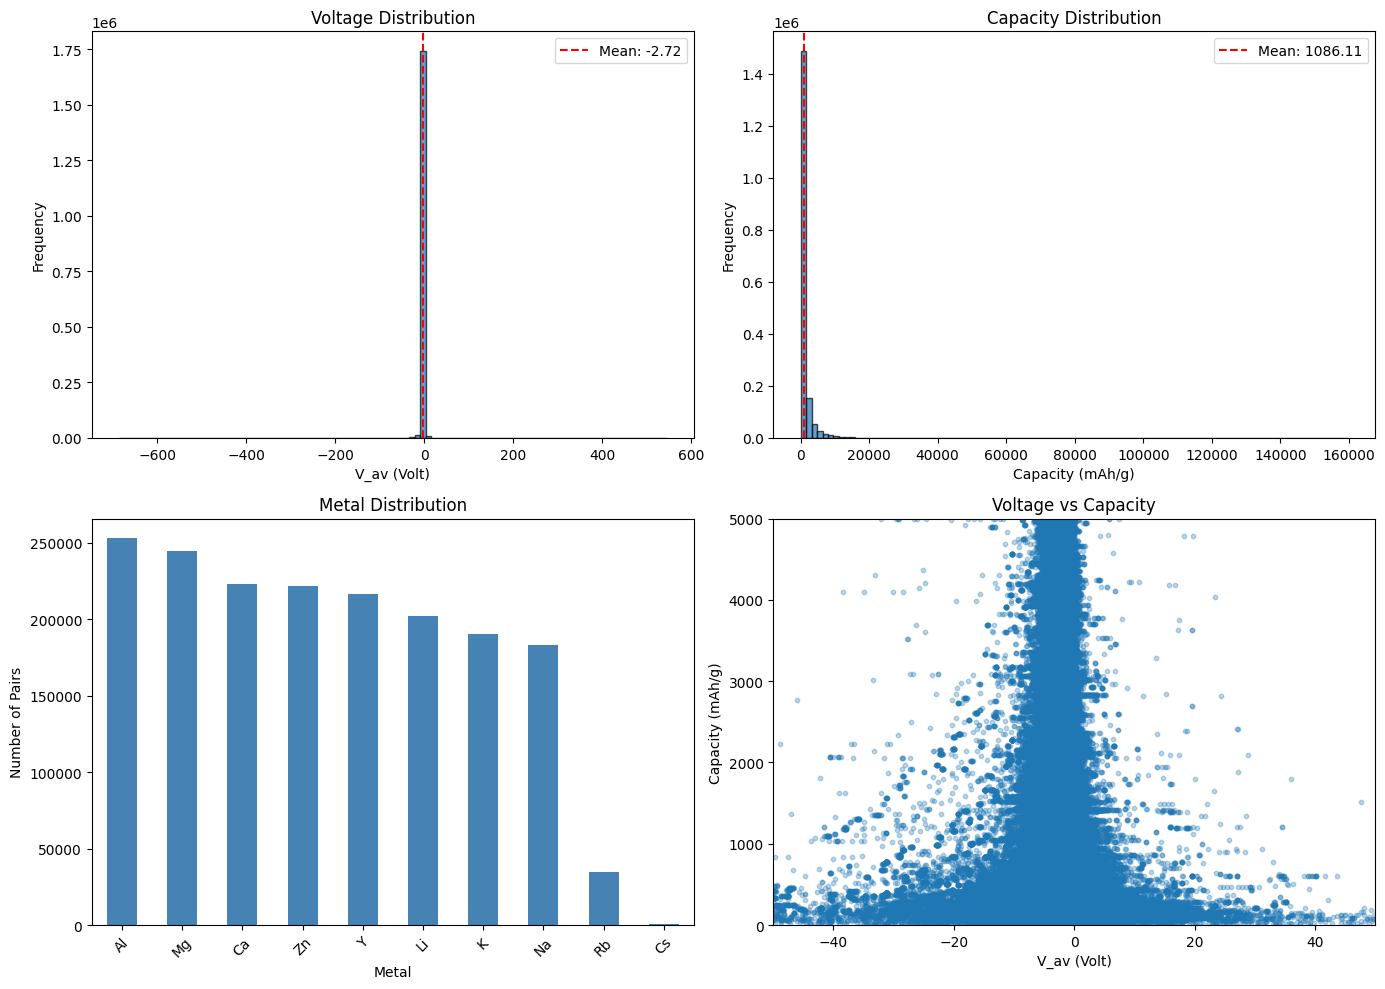

📊 Visualisasi tersimpan ke: data/dataset_statistics.png


In [20]:
# ============================================================================
# (OPSIONAL) VISUALISASI DATA DISTRIBUTION
# ============================================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Voltage distribution
axes[0, 0].hist(df_raw["V_av"], bins=100, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel("V_av (Volt)")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].set_title("Voltage Distribution")
axes[0, 0].axvline(df_raw["V_av"].mean(), color='r', linestyle='--', 
                   label=f'Mean: {df_raw["V_av"].mean():.2f}')
axes[0, 0].legend()

# Capacity distribution
axes[0, 1].hist(df_raw["capacity_mAh_g"], bins=100, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel("Capacity (mAh/g)")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].set_title("Capacity Distribution")
axes[0, 1].axvline(df_raw["capacity_mAh_g"].mean(), color='r', linestyle='--',
                   label=f'Mean: {df_raw["capacity_mAh_g"].mean():.2f}')
axes[0, 1].legend()

# Metal distribution
metal_counts.plot(kind='bar', ax=axes[1, 0], color='steelblue')
axes[1, 0].set_xlabel("Metal")
axes[1, 0].set_ylabel("Number of Pairs")
axes[1, 0].set_title("Metal Distribution")
axes[1, 0].tick_params(axis='x', rotation=45)

# V_av vs Capacity scatter (with zoom)
axes[1, 1].scatter(df_raw["V_av"], df_raw["capacity_mAh_g"], alpha=0.3, s=10)
axes[1, 1].set_xlabel("V_av (Volt)")
axes[1, 1].set_ylabel("Capacity (mAh/g)")
axes[1, 1].set_title("Voltage vs Capacity")
axes[1, 1].set_xlim(-50, 50)  # Zoom in untuk melihat pattern
axes[1, 1].set_ylim(0, 5000)

plt.tight_layout()
plt.savefig("data/dataset_statistics.png", dpi=150, bbox_inches='tight')
plt.show()

print("📊 Visualisasi tersimpan ke: data/dataset_statistics.png")

In [23]:
df_raw

,metal,valence,discharged_id,discharged_formula,charged_id,charged_formula,discharged_sg,charged_sg,discharged_cs,charged_cs,x1_charged,x2_discharged,V_av,dV_percent,capacity_mAh_g,specific_energy_Wh_kg
0,Li,1,aflow:06d5d56761b18d84,KLiCO3,mp-3346520,KCO3,14,14.0,None,Monoclinic,0.0,4.0,-5.8378,29.6993,252.7284,-1475.3850
1,Li,1,aflow:06d5d56761b18d84,KLiCO3,aflow:892e14f52a14b344,KCO3,14,221.0,None,None,0.0,4.0,13.3682,101.1236,252.7284,3378.5344
2,Li,1,aflow:06d5d56761b18d84,KLiCO3,aflow:7359ab301ed57314,KCO3,14,14.0,None,None,0.0,8.0,2.9320,20.6880,505.4567,1482.0212
3,Li,1,aflow:02e0e7530239d975,LiCa2Mg,mp-3346969,Ca2Mg,225,139.0,None,Tetragonal,0.0,2.0,-13.1203,18.4880,481.1653,-6313.0286
4,Li,1,aflow:1a8d3d8f780ad0ad,LiCa2Mg,mp-3346969,Ca2Mg,123,139.0,None,Tetragonal,0.0,2.0,-13.1135,18.0547,481.1653,-6309.7759
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1770805,Y,3,aflow:368e3e02806c24bb,CaY2W,aflow:97dde84c8d8168c6,CaYW,10,156.0,None,None,1.0,2.0,-4.7090,35.5958,200.1449,-942.4759
1770806,Y,3,aflow:4be0d42b134a230f,CaY2W,aflow:97dde84c8d8168c6,CaYW,139,156.0,None,None,1.0,2.0,-4.5503,35.4378,200.1449,-910.7263
1770807,Y,3,aflow:4d4fb6b0ddf25d6a,CaY2W,aflow:97dde84c8d8168c6,CaYW,6,156.0,None,None,1.0,2.0,-4.5973,42.2510,200.1449,-920.1197
1770808,Y,3,aflow:741b22d6383404a2,CaY2W,aflow:97dde84c8d8168c6,CaYW,166,156.0,None,None,1.0,2.0,-4.5382,52.1104,200.1449,-908.3045


In [22]:
df.head()

,id,formula,composition,nsites,volume,energy_cell,space_group,crystal_system
0,mp-3346412,Na2CaMg(SO4)3,"{'Na': 12, 'Ca': 6, 'Mg': 6, 'S': 18, 'O': 72}",114,1496.311135,-930.446643,1,Triclinic
1,mp-3346398,CaMg(CO3)2,"{'Ca': 3, 'Mg': 3, 'C': 6, 'O': 18}",30,317.483993,-269.894833,2,Triclinic
2,mp-3346453,LiMgCl3,"{'Li': 6, 'Mg': 6, 'Cl': 18}",30,598.728603,-211.452592,148,Trigonal
3,mp-3346415,CaMg15(CO3)16,"{'Ca': 1, 'Mg': 15, 'C': 16, 'O': 48}",80,754.484889,-692.205680,148,Trigonal
4,mp-3346392,CaMg(CO3)2,"{'Ca': 2, 'Mg': 2, 'C': 4, 'O': 12}",20,214.413183,-179.700132,14,Monoclinic
